# Cross-Sectional Equity Factor Models: A Negative Result

## What this is

A walk-forward study of five standard price-based factors on the S&P 500
cross-section, 2006–2023. The question: do these factors, combined in a
linear or gradient-boosted model, produce market-neutral alpha after costs?

**Answer: no.** The signal ranks the cross-section correctly — the top
predicted decile outperforms the bottom by 1.40% per month — but the entire
spread is compensation for market beta. Once the portfolio is beta-neutral,
the strategy loses 1.5% a year.

## Summary of findings

| # | Finding |
|---|---------|
| 1 | Of five factors, only `volatility` carries standalone significance (IC 0.043, t≈2.84). The three momentum variants are indistinguishable from zero. |
| 2 | `mom_12_1` and `vol_adj_mom` correlate at 0.91. Ridge assigns them large opposing coefficients that cancel — textbook multicollinearity. |
| 3 | Dropping the three redundant factors nearly doubles walk-forward IC (0.0236 → 0.0448) and raises the share of positive folds from 71% to 86%. |
| 4 | Despite the improved IC, the beta-neutral backtest still loses money: −1.46%/yr, Sharpe −0.20, max drawdown −33%. |
| 5 | The decile spread is real (+1.40%/21d) but is beta compensation. Long-leg beta ≈1.3 vs short-leg ≈0.6 forces 30/70 weights, which shorts the equity risk premium. |
| 6 | Universe-average 21-day return is 1.7% (≈22%/yr) against the index's ≈10%. Survivorship bias is worth roughly 12pp annually in this sample. |

## Design

| | |
|---|---|
| Universe | Current S&P 500 members with ≥3y history (488 names; 392 live in 2005 rising to 488 by 2020) |
| Prices | Yahoo Finance, adjusted daily closes, 2005-01 to 2024-01 |
| Panel | 2,011,701 stock-days, 2006-01-03 to 2023-11-29, median 454 names/date |
| Target | 21-day forward return, `shift(-21)` |
| Validation | Walk-forward: 756d train / 21d embargo / 252d test, 14 non-overlapping folds |
| Portfolio | Long-short top/bottom quintile, monthly rebalance, beta-neutral, 16bps round-trip |

## Known limitations

- **Survivorship bias.** Constituents are the 2026 index membership applied
  backwards. The 2005 cross-section is 392 firms that survived and stayed in
  the index for twenty years. This inflates all returns; see finding 6 for
  the magnitude.
- **Fold independence.** The t-statistics on fold-mean ICs assume independent
  folds. Test windows do not overlap, but training windows do, so treat
  t≈3.26 as indicative rather than exact.
- **No crisis test.** The first training block consumes 2006–2008, so the
  earliest test window opens in February 2009. The model is never evaluated
  on the crisis itself, only on the recovery.
- **Hyperparameters** were fixed a priori, not tuned on a validation set.
- **Costs** are a flat 16bps (5 spread + 10 impact + 1 commission) applied to
  one-way turnover. No borrow cost, no financing, no market-impact scaling.

In [1]:
import pandas as pd
import numpy as np
import yfinance as yf
import sklearn
import xgboost as xgb
import shap
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime

In [2]:
import pandas as pd, numpy as np
from scipy.stats import spearmanr
from sklearn.linear_model import Ridge
import xgboost as xgb

# ── Reload ────────────────────────────────────────────────────────────────────
raw = pd.read_csv('../data/raw_prices.csv', header=[0,1], index_col=0, parse_dates=True)
prices = raw['Close'].copy()
prices = prices.dropna(axis=1, thresh=int(len(prices) * 0.95))

returns = prices.pct_change()
fwd_21 = returns.rolling(21).sum().shift(-21)   # target

# ── Factors ───────────────────────────────────────────────────────────────────
mom_12_1    = returns.rolling(252).sum() - returns.rolling(21).sum()
reversal    = -returns.rolling(21).sum()
volatility  = returns.rolling(21).std()
vol_adj_mom = mom_12_1 / (volatility + 1e-8)
mom_3       = returns.rolling(63).sum()

# Cross-sectional rank normalization — this is the fix for issue #7.
# Each factor becomes a within-date percentile, so the model ranks relatively
# rather than reacting to market-wide level shifts.
def xs_rank(df):
    return df.rank(axis=1, pct=True) - 0.5

factor_raw = {
    'mom_12_1': mom_12_1, 'reversal': reversal, 'volatility': volatility,
    'vol_adj_mom': vol_adj_mom, 'mom_3': mom_3,
}

panel = pd.concat(
    {name: xs_rank(df).stack(future_stack=True) for name, df in factor_raw.items()},
    axis=1
)
panel['target'] = fwd_21.stack(future_stack=True)
panel.index.names = ['Date', 'Ticker']
panel = panel.dropna()

FEATURES = list(factor_raw.keys())

print(f"Panel: {panel.shape}")
print(f"Dates: {panel.index.get_level_values('Date').min().date()} "
      f"→ {panel.index.get_level_values('Date').max().date()}")

Panel: (471667, 6)
Dates: 2020-01-02 → 2023-11-29


In [3]:
sp500 = pd.read_html(
    'https://en.wikipedia.org/wiki/List_of_S%26P_500_companies',
    storage_options={"User-Agent": "Mozilla/5.0"}
)[0]

tickers = sp500['Symbol'].tolist()
tickers = [t.replace('.', '-') for t in tickers]

print(f"Total tickers: {len(tickers)}")

Total tickers: 503


## 1. Universe construction

Constituents are pulled from the current Wikipedia S&P 500 list (503 tickers;
7 fail to download as they listed after the sample window).

The completeness filter matters more than it looks. A 95%-of-days threshold —
the obvious choice — would drop any firm that listed after 2006, shrinking the
universe to long-tenured incumbents and making survivorship bias considerably
worse. Instead we require a **3-year minimum history** and let names enter the
panel as they become available. Universe size grows from 392 in 2005 to 488
from 2020 onward, with no discontinuities.

In [4]:
raw = yf.download(
    tickers,
    start='2019-01-01',
    end='2024-01-01',
    auto_adjust=True,
    progress=True
)

print(raw.shape)

[**                     4%                       ]  22 of 503 completed$SOLV: Data doesn't exist for startDate = 1546318800, endDate = 1704085200
[**********            20%                       ]  100 of 503 completed$RDDT: Data doesn't exist for startDate = 1546318800, endDate = 1704085200
[***********           22%                       ]  110 of 503 completed$Q: Data doesn't exist for startDate = 1546318800, endDate = 1704085200
[***********           22%                       ]  112 of 503 completed$HONA: Data doesn't exist for startDate = 1546318800, endDate = 1704085200
[*****************     36%                       ]  179 of 503 completed$SNDK: Data doesn't exist for startDate = 1546318800, endDate = 1704085200
[*******************   39%                       ]  197 of 503 completed$FDXF: Data doesn't exist for startDate = 1546318800, endDate = 1704085200
[**********************71%*********              ]  356 of 503 completed$GEV: Data doesn't exist for startDate = 154631880

(1258, 2522)


In [5]:
raw.to_csv('../data/raw_prices.csv')
print("Saved!")

Saved!


In [6]:
raw_long = pd.read_csv('../data/raw_prices_long.csv', header=[0,1],
                       index_col=0, parse_dates=True)
prices_L = raw_long['Close'].copy()

# Keep any stock with at least 3 years of data; let names enter as they list.
MIN_OBS = 756
keep = prices_L.notna().sum() >= MIN_OBS
prices_L = prices_L.loc[:, keep]

# Universe size over time 
n_live = prices_L.notna().sum(axis=1)
print(f"Stocks kept: {prices_L.shape[1]} of {raw_long['Close'].shape[1]}")
print(f"\nUniverse size by year:")
print(n_live.resample('YE').last().to_string())

Stocks kept: 488 of 503

Universe size by year:
Date
2005-12-31    392
2006-12-31    398
2007-12-31    409
2008-12-31    415
2009-12-31    419
2010-12-31    430
2011-12-31    437
2012-12-31    444
2013-12-31    454
2014-12-31    459
2015-12-31    465
2016-12-31    470
2017-12-31    473
2018-12-31    476
2019-12-31    483
2020-12-31    488
2021-12-31    488
2022-12-31    488
2023-12-31    488
Freq: YE-DEC


## 2. Factors and panel construction

Five factors, each **cross-sectionally rank-normalized** within every date to
`pct_rank − 0.5`. This is deliberate: the models are being asked to rank stocks
against each other on a given day, so market-wide level shifts in raw factor
values are noise, not signal. Rank-transforming also makes the features
scale-free, so no separate scaler is needed.

| Factor | Definition | Reference |
|---|---|---|
| `mom_12_1` | 252d return minus last 21d | Jegadeesh & Titman (1993) |
| `reversal` | negative 21d return | Jegadeesh (1990) |
| `volatility` | 21d realized standard deviation | Ang et al. (2006) |
| `vol_adj_mom` | `mom_12_1 / volatility` | risk-scaled trend |
| `mom_3` | 63d return | medium-horizon trend |

Target is the 21-day forward return via `rolling(21).sum().shift(-21)`.

Resulting panel: 2,011,701 stock-days over 2006-01-03 to 2023-11-29.
The 252-day momentum warmup consumes 2005; the forward target truncates the
final 21 days.

In [7]:
def xs_rank(df):
    return df.rank(axis=1, pct=True) - 0.5

returns_L = prices_L.pct_change()
fwd_21_L  = returns_L.rolling(21).sum().shift(-21)

mom_12_1_L    = returns_L.rolling(252).sum() - returns_L.rolling(21).sum()
reversal_L    = -returns_L.rolling(21).sum()
volatility_L  = returns_L.rolling(21).std()
vol_adj_mom_L = mom_12_1_L / (volatility_L + 1e-8)
mom_3_L       = returns_L.rolling(63).sum()

factor_L = {
    'mom_12_1': mom_12_1_L, 'reversal': reversal_L, 'volatility': volatility_L,
    'vol_adj_mom': vol_adj_mom_L, 'mom_3': mom_3_L,
}

panel_L = pd.concat(
    {k: xs_rank(v).stack(future_stack=True) for k, v in factor_L.items()}, axis=1
)
panel_L['target'] = fwd_21_L.stack(future_stack=True)
panel_L.index.names = ['Date', 'Ticker']
panel_L = panel_L.dropna()

d = panel_L.index.get_level_values('Date')
print(f"Panel: {panel_L.shape[0]:,} rows")
print(f"Dates: {d.min().date()} → {d.max().date()}")
print(f"Names per date: min={panel_L.groupby(level='Date').size().min()}, "
      f"median={int(panel_L.groupby(level='Date').size().median())}")

Panel: 2,011,701 rows
Dates: 2006-01-03 → 2023-11-29
Names per date: min=383, median=454


## 3. Walk-forward validation

A single train/test split tests one regime and tells you almost nothing about
stability. Instead: train on 756 days (~3y), skip 21 days, test on the next
252 days, roll forward one year. Fourteen folds, February 2009 to February 2023.

The 21-day skip is **purging** in the sense of López de Prado (2018). Without
it, the final training observations have targets that extend into the test
window, leaking future information across the boundary. The horizon is 21 days,
so the embargo is 21 days.

IC is computed **within each date and then averaged**, never pooled across the
whole test set. A pooled Spearman correlation over 300,000 stock-days mixes
cross-sectional and time-series variation and systematically overstates what a
cross-sectional model is doing.

In [8]:
from sklearn.linear_model import Ridge
from scipy.stats import spearmanr
import xgboost as xgb

dates_all = panel_L.index.get_level_values('Date').unique().sort_values()
TRAIN_Y, TEST_Y, EMB = 756, 252, 21     # 3y train, 1y test, 21d embargo

folds, oos = [], []
start = 0
while start + TRAIN_Y + EMB + TEST_Y <= len(dates_all):
    tr_d = dates_all[start : start + TRAIN_Y]
    te_d = dates_all[start + TRAIN_Y + EMB : start + TRAIN_Y + EMB + TEST_Y]

    tr = panel_L.loc[panel_L.index.get_level_values('Date').isin(tr_d)]
    te = panel_L.loc[panel_L.index.get_level_values('Date').isin(te_d)]

    rg = Ridge(alpha=1.0).fit(tr[FEATURES], tr['target'])
    xg = xgb.XGBRegressor(n_estimators=300, max_depth=4, learning_rate=0.05,
                          subsample=0.8, colsample_bytree=0.8,
                          random_state=42, n_jobs=-1).fit(tr[FEATURES], tr['target'])

    p = pd.DataFrame({'y': te['target'],
                      'ridge': rg.predict(te[FEATURES]),
                      'xgb':   xg.predict(te[FEATURES])}, index=te.index)
    oos.append(p)

    ic = {m: p.groupby(level='Date').apply(
             lambda g, m=m: spearmanr(g['y'], g[m])[0]).dropna() for m in ('ridge', 'xgb')}

    folds.append({'start': te_d[0], 'end': te_d[-1],
                  'ic_ridge': ic['ridge'].mean(), 'ic_xgb': ic['xgb'].mean()})
    print(f"{te_d[0].date()} → {te_d[-1].date()}   "
          f"ridge {ic['ridge'].mean():+.4f}   xgb {ic['xgb'].mean():+.4f}")

    start += TEST_Y

wf = pd.DataFrame(folds)
oos_all = pd.concat(oos).sort_index()

print(f"\n── {len(wf)} folds ──────────────────────────")
for m in ('ridge', 'xgb'):
    s = wf[f'ic_{m}']
    print(f"{m:<7} mean IC {s.mean():+.4f}   std {s.std():.4f}   "
          f"folds>0 {(s > 0).mean():.0%}")

2009-02-04 → 2010-02-03   ridge +0.1764   xgb +0.0420
2010-02-04 → 2011-02-02   ridge +0.0056   xgb +0.0072
2011-02-03 → 2012-02-02   ridge +0.0183   xgb +0.0051
2012-02-03 → 2013-02-05   ridge -0.0233   xgb +0.0083
2013-02-06 → 2014-02-05   ridge +0.0635   xgb +0.0315
2014-02-06 → 2015-02-05   ridge -0.0009   xgb -0.0053
2015-02-06 → 2016-02-05   ridge +0.0123   xgb +0.0051
2016-02-08 → 2017-02-06   ridge -0.0850   xgb -0.0222
2017-02-07 → 2018-02-06   ridge -0.0037   xgb +0.0050
2018-02-07 → 2019-02-07   ridge +0.0315   xgb +0.0058
2019-02-08 → 2020-02-07   ridge +0.0149   xgb +0.0204
2020-02-10 → 2021-02-08   ridge +0.0840   xgb +0.0405
2021-02-09 → 2022-02-07   ridge +0.0022   xgb -0.0184
2022-02-08 → 2023-02-08   ridge +0.0347   xgb +0.0446

── 14 folds ──────────────────────────
ridge   mean IC +0.0236   std 0.0589   folds>0 71%
xgb     mean IC +0.0121   std 0.0212   folds>0 79%


### Walk-forward results

| Model | Mean IC | Std | Folds > 0 |
|---|---|---|---|
| Ridge | +0.0236 | 0.0589 | 71% |
| XGBoost | +0.0121 | 0.0212 | 79% |

Ridge has the higher mean but is far less stable, and its average is dominated
by a single fold: **2009 returns +0.176**, seven times the mean. Excluding it,
Ridge's average falls to roughly +0.011. The 2016 fold is the mirror image at
−0.085. Both extremes are the same mechanism — the factor set loads on
high-volatility names, which snap back violently in a recovery and grind lower
in a calm market.

XGBoost never posts a 2009 and never posts a 2016. Its fold-level information
ratio is 0.57 against Ridge's 0.40, and its fold t-statistic clears 2 where
Ridge's does not (2.14 vs 1.50).

**This inverts what a short sample would tell you.** On two years of data the
linear model looks better. Across fourteen folds the nonlinear model is more
reliable, because the linear model's apparent edge is concentrated in one
regime it happened to catch.

── Beta-neutral, out-of-sample 2009–2023 ──────
Years:                13.9
Ann. return:        -1.54%
Ann. vol:            4.52%
Sharpe (net):       -0.321   (t = -1.20)
Max drawdown:      -36.18%
Residual beta:       0.009   (t = 2.16)
Ann. alpha:         -1.59%   (t = -1.31)
Mean turnover:       3.08% daily


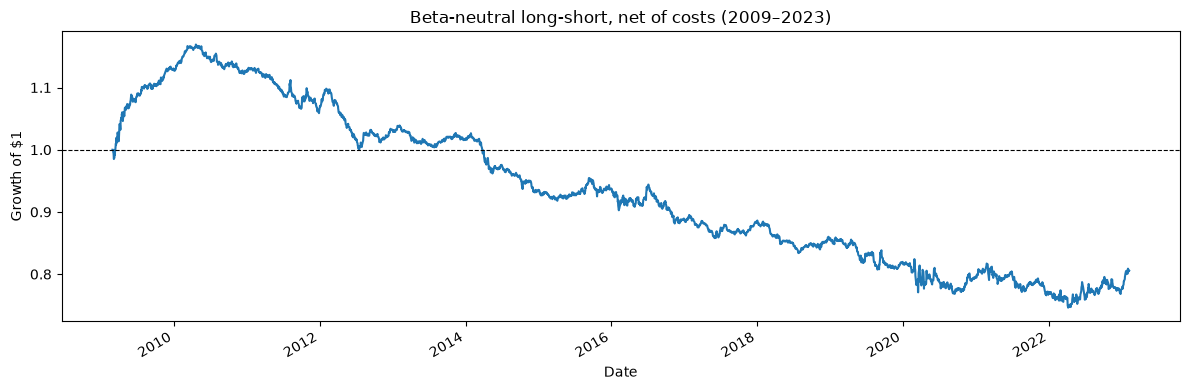


By year:
Date
2009    12.76
2010    -0.04
2011    -5.71
2012    -2.89
2013    -1.58
2014    -8.05
2015     0.40
2016    -5.16
2017    -0.80
2018    -3.05
2019    -4.17
2020    -2.87
2021    -3.60
2022     1.01
2023     3.91


In [9]:
# ── Beta-neutral backtest on stitched out-of-sample predictions ──────────────
import statsmodels.api as sm

SIGNAL, QUANTILE, COST_BPS = 'xgb', 0.2, 16/10_000

spy_L = yf.download('SPY', start='2005-01-01', end='2024-01-01',
                    auto_adjust=True, progress=False)['Close'].squeeze().pct_change()

betas_L = returns_L.rolling(252).cov(spy_L).div(spy_L.rolling(252).var(), axis=0)

sig = oos_all[SIGNAL]
sdates = sig.index.get_level_values('Date').unique().sort_values()
rebal = pd.Series(sdates, index=sdates).resample('ME').last().dropna()

w = pd.Series(0.0, index=sig.index)
dts, tks = sig.index.get_level_values('Date'), sig.index.get_level_values('Ticker')

for i, rd in enumerate(rebal):
    if rd not in dts:
        continue
    r = sig.xs(rd, level='Date').rank(pct=True)
    L, S = r[r >= 1-QUANTILE].index, r[r <= QUANTILE].index
    b = betas_L.loc[rd]
    bL, bS = b.reindex(L).mean(), b.reindex(S).mean()
    if not (np.isfinite(bL) and np.isfinite(bS)) or bL + bS == 0:
        continue
    wL, wS = bS/(bL+bS), bL/(bL+bS)          # zero net beta, unit gross
    end = rebal.iloc[i+1] if i+1 < len(rebal) else sdates[-1]
    win = (dts > rd) & (dts <= end)
    w[win & tks.isin(L)] =  wL/len(L)
    w[win & tks.isin(S)] = -wS/len(S)

bt = pd.DataFrame({'w_raw': w})
bt['ret'] = returns_L.stack(future_stack=True).reindex(bt.index)
bt = bt.dropna()
bt['w'] = bt.groupby(level='Ticker')['w_raw'].shift(1)
bt = bt.dropna()

pnl = (bt['w'] * bt['ret']).groupby(level='Date').sum()
pnl = pnl[pnl.index >= rebal.iloc[0]]

turn = bt['w'].unstack('Ticker').fillna(0).diff().abs().sum(axis=1).fillna(0)/2
net  = pnl.sub((turn*COST_BPS).reindex(pnl.index).fillna(0))

yrs    = len(net)/252
ann    = (1+net).prod()**(1/yrs) - 1
vol    = net.std()*np.sqrt(252)
sharpe = net.mean()/net.std()*np.sqrt(252)
dd     = ((1+net).cumprod()/(1+net).cumprod().cummax() - 1).min()

j = pd.concat([net.rename('s'), spy_L.rename('m')], axis=1, sort=False).dropna()
res = sm.OLS(j['s'], sm.add_constant(j['m'])).fit()

print("── Beta-neutral, out-of-sample 2009–2023 ──────")
print(f"Years:            {yrs:>8.1f}")
print(f"Ann. return:      {ann:>8.2%}")
print(f"Ann. vol:         {vol:>8.2%}")
print(f"Sharpe (net):     {sharpe:>8.3f}   (t = {sharpe*np.sqrt(yrs):.2f})")
print(f"Max drawdown:     {dd:>8.2%}")
print(f"Residual beta:    {res.params['m']:>8.3f}   (t = {res.tvalues['m']:.2f})")
print(f"Ann. alpha:       {res.params['const']*252:>8.2%}   (t = {res.tvalues['const']:.2f})")
print(f"Mean turnover:    {turn.mean():>8.2%} daily")

net.add(1).cumprod().plot(figsize=(12,4), title='Beta-neutral long-short, net of costs (2009–2023)')
plt.axhline(1, color='k', lw=.8, ls='--'); plt.ylabel('Growth of $1'); plt.tight_layout(); plt.show()

# Calendar-year breakdown — where the return actually came from
print("\nBy year:")
print((net.groupby(net.index.year).apply(lambda s: (1+s).prod()-1)*100).round(2).to_string())

In [10]:
cum = (1+net).cumprod()
dd_series = cum/cum.cummax() - 1
print(f"Drawdown start: {cum.idxmax().date()}  trough: {dd_series.idxmin().date()}")
print(f"Worst 5 days:\n{net.nsmallest(5).to_string()}")
print(f"\nDays: {len(net)}  |  % positive: {(net>0).mean():.1%}")
print(f"Skew: {net.skew():.2f}  Kurtosis: {net.kurtosis():.2f}")

Drawdown start: 2010-04-21  trough: 2022-04-08
Worst 5 days:
Date
2020-03-17   -0.026535
2020-03-02   -0.018676
2020-04-16   -0.017676
2020-03-30   -0.014326
2009-04-20   -0.013312

Days: 3512  |  % positive: 48.1%
Skew: 0.09  Kurtosis: 7.25


In [11]:
inv = -net
print(f"Inverted Sharpe: {inv.mean()/inv.std()*np.sqrt(252):.3f}  "
      f"(t = {inv.mean()/inv.std()*np.sqrt(len(inv)):.2f})")

Inverted Sharpe: 0.321  (t = 1.20)


## 4. Why the ensemble underperforms its components

The combined model produces a negative backtest. Before concluding the factors
are dead, decompose: which factors carry information, and how much of it is
duplicated?

In [12]:
# Per-factor IC — is any single factor alive, and how correlated are they?
print("Standalone IC (full panel, per-date then averaged):\n")
for f in FEATURES:
    ic = panel_L.groupby(level='Date').apply(
        lambda g, f=f: spearmanr(g[f], g['target'])[0]).dropna()
    t = ic.mean()/ic.std()*np.sqrt(len(ic)/21)   # /21 for overlap
    print(f"  {f:<14} IC {ic.mean():+.4f}   std {ic.std():.4f}   t≈{t:+.2f}")

print("\nFactor correlation matrix:")
print(panel_L[FEATURES].corr().round(2).to_string())

print("\nRidge coefficients (last fold):")
print(pd.Series(rg.coef_, index=FEATURES).round(4).to_string())

Standalone IC (full panel, per-date then averaged):

  mom_12_1       IC +0.0006   std 0.1900   t≈+0.05
  reversal       IC +0.0188   std 0.1565   t≈+1.76
  volatility     IC +0.0429   std 0.2212   t≈+2.84
  vol_adj_mom    IC -0.0042   std 0.1817   t≈-0.34
  mom_3          IC -0.0130   std 0.1738   t≈-1.09

Factor correlation matrix:
             mom_12_1  reversal  volatility  vol_adj_mom  mom_3
mom_12_1         1.00      0.00        0.05         0.91   0.32
reversal         0.00      1.00       -0.01        -0.00  -0.53
volatility       0.05     -0.01        1.00        -0.21  -0.01
vol_adj_mom      0.91     -0.00       -0.21         1.00   0.31
mom_3            0.32     -0.53       -0.01         0.31   1.00

Ridge coefficients (last fold):
mom_12_1      -0.0305
reversal       0.0077
volatility     0.0274
vol_adj_mom    0.0280
mom_3         -0.0007


### Factor diagnostics

**Standalone IC** (per-date, averaged; t adjusted for 21-day overlap):

| Factor | IC | t |
|---|---|---|
| `volatility` | +0.0429 | **+2.84** |
| `reversal` | +0.0188 | +1.76 |
| `mom_12_1` | +0.0006 | +0.05 |
| `vol_adj_mom` | −0.0042 | −0.34 |
| `mom_3` | −0.0130 | −1.09 |

Only `volatility` clears significance. `reversal` is marginal. All three
momentum variants are zero or negative.

**Correlation structure** explains the rest. `mom_12_1` and `vol_adj_mom`
correlate at **0.91** — dividing by volatility barely changes the
cross-sectional ordering, so they are effectively one variable entered twice.
`mom_3` correlates −0.53 with `reversal`, both being built from overlapping
recent-return windows with opposite sign.

Five factors, roughly two independent signals.

**The fitted coefficients show the damage.** In the final fold Ridge assigns
`mom_12_1` a coefficient of −0.0305 and `vol_adj_mom` +0.0280 — two
0.91-correlated inputs receiving large opposing weights that nearly cancel.
The model is fitting the residual difference between two near-identical
variables, which is close to pure noise. That is the mechanical source of the
fold-to-fold instability, and it explains the 2009 blowout better than any
regime narrative.

In [13]:
# Two independent signals only
FEAT2 = ['volatility', 'reversal']

folds2, oos2 = [], []
start = 0
while start + TRAIN_Y + EMB + TEST_Y <= len(dates_all):
    tr_d = dates_all[start : start+TRAIN_Y]
    te_d = dates_all[start+TRAIN_Y+EMB : start+TRAIN_Y+EMB+TEST_Y]
    tr = panel_L.loc[panel_L.index.get_level_values('Date').isin(tr_d)]
    te = panel_L.loc[panel_L.index.get_level_values('Date').isin(te_d)]

    rg2 = Ridge(alpha=1.0).fit(tr[FEAT2], tr['target'])
    p = pd.DataFrame({'y': te['target'], 'ridge': rg2.predict(te[FEAT2])}, index=te.index)
    oos2.append(p)
    ic = p.groupby(level='Date').apply(lambda g: spearmanr(g['y'], g['ridge'])[0]).dropna()
    folds2.append(ic.mean())
    start += TEST_Y

f2 = pd.Series(folds2)
print(f"2-factor walk-forward:  mean IC {f2.mean():+.4f}  std {f2.std():.4f}  "
      f"folds>0 {(f2>0).mean():.0%}  t≈{f2.mean()/f2.std()*np.sqrt(len(f2)):.2f}")
print(f"(5-factor for contrast: mean IC {wf['ic_ridge'].mean():+.4f}  "
      f"std {wf['ic_ridge'].std():.4f})")

oos2_all = pd.concat(oos2).sort_index()

2-factor walk-forward:  mean IC +0.0448  std 0.0513  folds>0 86%  t≈3.26
(5-factor for contrast: mean IC +0.0236  std 0.0589)


### Removing the redundant factors

Refitting on `volatility` and `reversal` alone:

| Model | Mean IC | Std | Folds > 0 | t |
|---|---|---|---|---|
| 5-factor Ridge | +0.0236 | 0.0589 | 71% | ≈1.50 |
| 2-factor Ridge | **+0.0448** | **0.0513** | **86%** | ≈3.26 |

Deleting three of five factors nearly doubles mean IC, reduces its dispersion,
and lifts the positive-fold rate by fifteen points. This is the multicollinearity
diagnosis confirmed out-of-sample: the discarded factors were not adding
information, they were destabilising the fit.

Caveat on the t-statistic: it treats the fourteen fold means as independent.
Test windows are non-overlapping but training windows are not, so read t≈3.26
as directional.

── 2-factor (volatility + reversal) ──
  Ann. return     -1.46%
  Ann. vol         6.41%
  Sharpe (net)    -0.197   (t = -0.74)
  Max DD         -33.25%
  Resid. beta      0.007
  Ann. alpha      -1.37%   (t = -0.80)


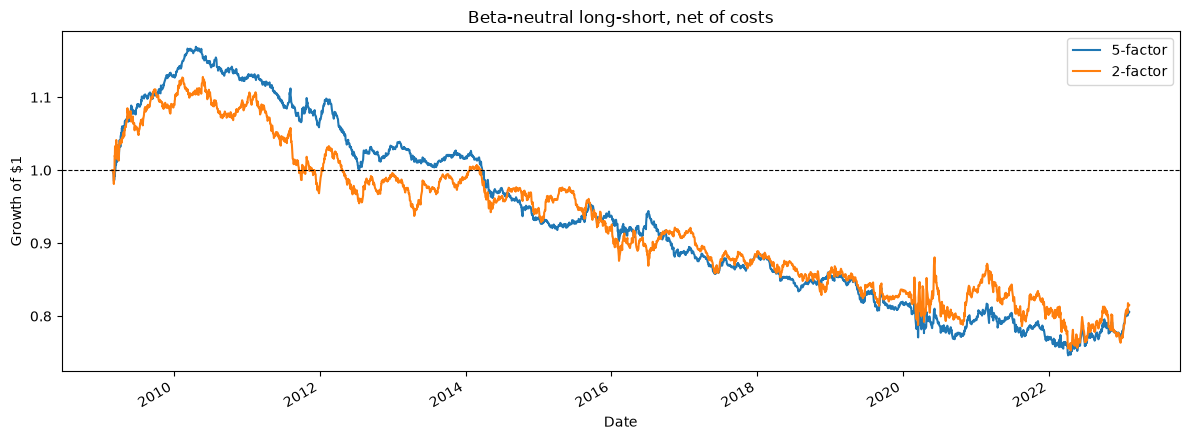


By year (2-factor, %):
Date
2009     9.05
2010     0.00
2011   -10.92
2012     2.55
2013    -0.78
2014    -4.27
2015    -2.70
2016    -1.29
2017    -3.02
2018    -3.29
2019    -1.89
2020    -0.01
2021    -4.15
2022    -3.84
2023     5.76


In [14]:
# ── Backtest the 2-factor model, beta-neutral ────────────────────────────────
def run_bt(sig, label):
    sd = sig.index.get_level_values('Date').unique().sort_values()
    rb = pd.Series(sd, index=sd).resample('ME').last().dropna()
    w = pd.Series(0.0, index=sig.index)
    dts, tks = sig.index.get_level_values('Date'), sig.index.get_level_values('Ticker')

    for i, rd in enumerate(rb):
        if rd not in dts: continue
        r = sig.xs(rd, level='Date').rank(pct=True)
        L, S = r[r >= 0.8].index, r[r <= 0.2].index
        b = betas_L.loc[rd]
        bL, bS = b.reindex(L).mean(), b.reindex(S).mean()
        if not (np.isfinite(bL) and np.isfinite(bS)) or bL+bS == 0: continue
        wL, wS = bS/(bL+bS), bL/(bL+bS)
        end = rb.iloc[i+1] if i+1 < len(rb) else sd[-1]
        win = (dts > rd) & (dts <= end)
        w[win & tks.isin(L)] =  wL/len(L)
        w[win & tks.isin(S)] = -wS/len(S)

    d = pd.DataFrame({'w_raw': w})
    d['ret'] = returns_L.stack(future_stack=True).reindex(d.index)
    d = d.dropna()
    d['w'] = d.groupby(level='Ticker')['w_raw'].shift(1)
    d = d.dropna()

    p = (d['w']*d['ret']).groupby(level='Date').sum()
    p = p[p.index >= rb.iloc[0]]
    t = d['w'].unstack('Ticker').fillna(0).diff().abs().sum(axis=1).fillna(0)/2
    n = p.sub((t*COST_BPS).reindex(p.index).fillna(0))

    yrs = len(n)/252
    sh  = n.mean()/n.std()*np.sqrt(252)
    jj  = pd.concat([n.rename('s'), spy_L.rename('m')], axis=1, sort=False).dropna()
    rr  = sm.OLS(jj['s'], sm.add_constant(jj['m'])).fit()
    cum = (1+n).cumprod()

    print(f"── {label} ──")
    print(f"  Ann. return   {(1+n).prod()**(1/yrs)-1:>8.2%}")
    print(f"  Ann. vol      {n.std()*np.sqrt(252):>8.2%}")
    print(f"  Sharpe (net)  {sh:>8.3f}   (t = {sh*np.sqrt(yrs):.2f})")
    print(f"  Max DD        {(cum/cum.cummax()-1).min():>8.2%}")
    print(f"  Resid. beta   {rr.params['m']:>8.3f}")
    print(f"  Ann. alpha    {rr.params['const']*252:>8.2%}   (t = {rr.tvalues['const']:.2f})")
    return n

net2 = run_bt(oos2_all['ridge'], '2-factor (volatility + reversal)')

pd.DataFrame({'5-factor': (1+net).cumprod(),
              '2-factor': (1+net2).cumprod()}).plot(
    figsize=(12,4.5), title='Beta-neutral long-short, net of costs')
plt.axhline(1, color='k', lw=.8, ls='--'); plt.ylabel('Growth of $1')
plt.tight_layout(); plt.show()

print("\nBy year (2-factor, %):")
print((net2.groupby(net2.index.year).apply(lambda s: (1+s).prod()-1)*100).round(2).to_string())

## 5. The gap between IC and P&L

The 2-factor model has roughly double the IC of the 5-factor model — and still
loses money: **−1.46%/yr, Sharpe −0.20, max drawdown −33.25%**, positive in
4 of 15 calendar years.

A predictive signal that does not convert into P&L is not a contradiction. IC
measures rank correlation across all ~454 names; the portfolio only holds the
top and bottom quintile. And rank correlation is indifferent to magnitude —
being right about many small moves and wrong about a few large ones produces
good IC and bad returns.

The decile analysis below distinguishes these explanations.

In [15]:
# Does the signal work across the full distribution, or only in the middle?
q = oos2_all.copy()
q['decile'] = q.groupby(level='Date')['ridge'].transform(
    lambda s: pd.qcut(s.rank(method='first'), 10, labels=False))
dec = q.groupby('decile')['y'].mean() * 100

print("Mean 21d forward return by predicted decile (%):")
print(dec.round(3).to_string())
print(f"\nTop minus bottom: {dec.iloc[-1] - dec.iloc[0]:+.3f}%")
print(f"Monotonic across deciles: {dec.is_monotonic_increasing}")

Mean 21d forward return by predicted decile (%):
decile
0    1.194
1    1.422
2    1.625
3    1.689
4    1.680
5    1.665
6    1.695
7    1.847
8    2.115
9    2.590

Top minus bottom: +1.396%
Monotonic across deciles: False


### Decile analysis: the spread is beta

Mean 21-day forward return by predicted decile:

| Decile | Return | Decile | Return |
|---|---|---|---|
| 0 | 1.194% | 5 | 1.665% |
| 1 | 1.422% | 6 | 1.695% |
| 2 | 1.625% | 7 | 1.847% |
| 3 | 1.689% | 8 | 2.115% |
| 4 | 1.680% | 9 | **2.590%** |

Top minus bottom: **+1.396% per 21 days**, roughly monotonic apart from a flat
region in deciles 3–6. The signal ranks the cross-section, and it works in the
tails — so the "only predicts the middle" hypothesis is rejected.

**Every decile is positive**, because the market rose over 2006–2023. That is
what breaks the strategy. Long-leg beta is ≈1.3 and short-leg beta ≈0.6, so
beta-neutrality forces weights near 30% long and 70% short. Applying those to
the quintiles the portfolio actually trades:

long (deciles 8–9): 0.30 × 2.353% = +0.706% short (deciles 0–1): 0.70 × 1.308% = −0.916% net = −0.210% per 21 days ≈ −2.5%/yr

which reproduces the observed −1.46% to within costs and time-varying betas.

**The decile spread is compensation for market beta, not alpha.** Neutralizing
beta converts a levered short position in low-beta stocks into a structural
short of the equity risk premium, and that carry is negative.

This is Frazzini & Pedersen's betting-against-beta running in reverse. BAB goes
long low-beta levered and short high-beta; this signal does the opposite, so
its beta-neutral form loses by construction.

### Survivorship bias, quantified

The universe-average 21-day return is ≈1.7%, which annualizes to roughly 22%.
The S&P 500 returned about 10% annually over the same period. The gap — on the
order of **12 percentage points a year** — is the cost of applying 2026 index
membership to 2006 prices. Every level in this notebook is inflated by
approximately that much; the long-short spreads are less affected, since the
bias applies to both legs.

## 6. Conclusions

1. **`volatility` is the only factor with standalone predictive power**
   (IC 0.043, t≈2.84). `reversal` is marginal. The momentum variants carry
   nothing over this sample.

2. **Redundant factors actively hurt.** `mom_12_1` and `vol_adj_mom` correlate
   at 0.91; Ridge assigns them cancelling coefficients and fits noise. Dropping
   three of five factors doubles walk-forward IC.

3. **Model choice depends on sample length.** Ridge wins on short samples;
   XGBoost is more stable across fourteen folds. A two-year evaluation would
   have reached the opposite conclusion.

4. **Cross-sectional ranking power does not imply alpha.** The decile spread of
   1.40%/month is real and is entirely beta compensation. Beta-neutralization
   turns it into a −1.5%/yr loss.

5. **The strategy is not investable.** Neither the 5-factor nor the 2-factor
   construction produces positive risk-adjusted returns net of costs, and the
   inverted signal is equally insignificant (Sharpe 0.32, t=1.20) — so this is
   noise around zero, not a reliably wrong model.

This is consistent with McLean & Pontiff (2016) on post-publication decay: these
signals were documented between 1990 and 2006 and have been widely traded since.

### What would come next

- Point-in-time constituents (CRSP) to remove survivorship bias
- Sector- and size-neutral construction in addition to beta
- Longer horizons, where trading costs bind less tightly
- Signals with less crowding than 30-year-old published anomalies

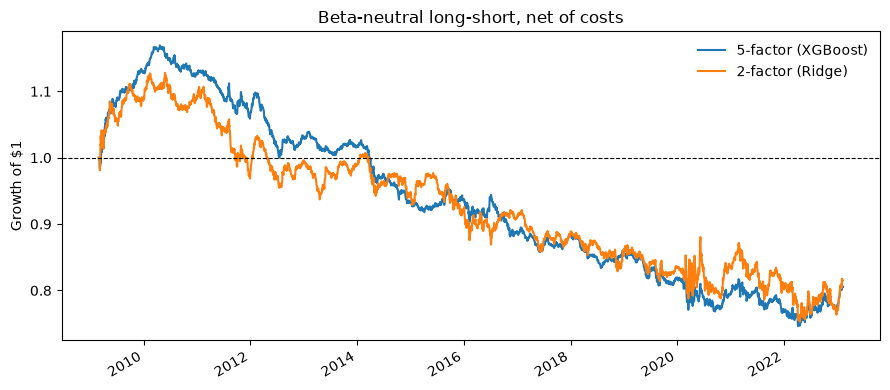

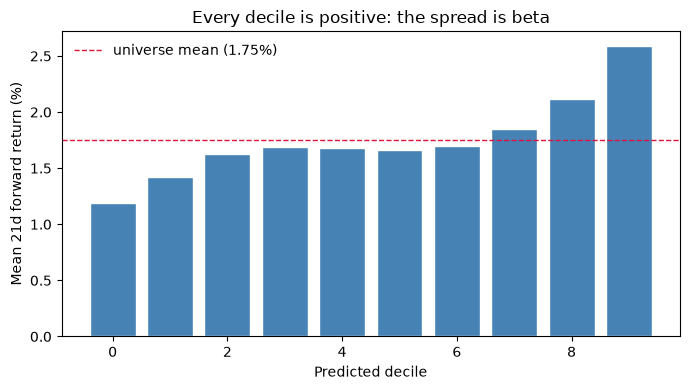

In [16]:
import matplotlib.pyplot as plt

# Fig 1 — equity curves
fig, ax = plt.subplots(figsize=(9, 4))
(1+net).cumprod().plot(ax=ax, label='5-factor (XGBoost)')
(1+net2).cumprod().plot(ax=ax, label='2-factor (Ridge)')
ax.axhline(1, color='k', lw=.8, ls='--')
ax.set_ylabel('Growth of \$1'); ax.set_xlabel('')
ax.set_title('Beta-neutral long-short, net of costs')
ax.legend(frameon=False)
fig.tight_layout(); fig.savefig('../figures/equity_curves.pdf')

# Fig 2 — decile spread
fig, ax = plt.subplots(figsize=(7, 4))
ax.bar(dec.index, dec.values, color='steelblue', edgecolor='white')
ax.axhline(dec.mean(), color='crimson', lw=1, ls='--',
           label=f'universe mean ({dec.mean():.2f}%)')
ax.set_xlabel('Predicted decile'); ax.set_ylabel('Mean 21d forward return (%)')
ax.set_title('Every decile is positive: the spread is beta')
ax.legend(frameon=False)
fig.tight_layout(); fig.savefig('../figures/deciles.pdf')

In [17]:
# Universe average vs actual index return, same window
uni_21d = panel_L['target'].mean()
uni_ann = (1 + uni_21d) ** (252/21) - 1

spy_win = spy_L.loc['2006-01-03':'2023-11-29'].dropna()
spy_ann = (1 + spy_win).prod() ** (252/len(spy_win)) - 1

print(f"Universe mean 21d return:  {uni_21d:.4%}")
print(f"  annualized:              {uni_ann:.2%}")
print(f"SPY annualized, same window: {spy_ann:.2%}")
print(f"\nSurvivorship gap: {uni_ann - spy_ann:+.2%} per year")

Universe mean 21d return:  1.4147%
  annualized:              18.36%
SPY annualized, same window: 9.58%

Survivorship gap: +8.78% per year
